# Task 1 - Data Preparation

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('q2_customers.csv')

# Display basic info
print("Shape:", df.shape)
print("\nPreview:\n", df.head())

# Initialize scaler
scaler = StandardScaler()

# Scale all features
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame for easier handling
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

# Verify scaled data
print("\nScaled Data Preview:\n", df_scaled.head())

Shape: (500, 6)

Preview:
    age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Scaled Data Preview:
         age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161    -0.827783   
4

**Why Scaling is Essential Before K-Means (Markdown)**


---


K-Means clustering is a distance-based algorithm that relies on Euclidean distance to assign points to clusters.

1) Features like annual_spend or basket_size may have much larger numeric ranges than features like visits_per_month.
2) Without scaling, variables with larger magnitudes will dominate the distance calculation, leading to biased clusters.
3) StandardScaler transforms all features to:

    a) Mean = 0

    b) Standard deviation = 1


---


**This ensures:**

1) Equal contribution of all features to clustering
2) More meaningful and balanced clusters
3) Faster and more stable convergence of the algorithm


---


**Conclusion:**
Scaling is critical to prevent distortion in cluster formation and to ensure that K-Means captures true underlying customer behavior patterns.

# Task 2 - Choosing K — Elbow Method

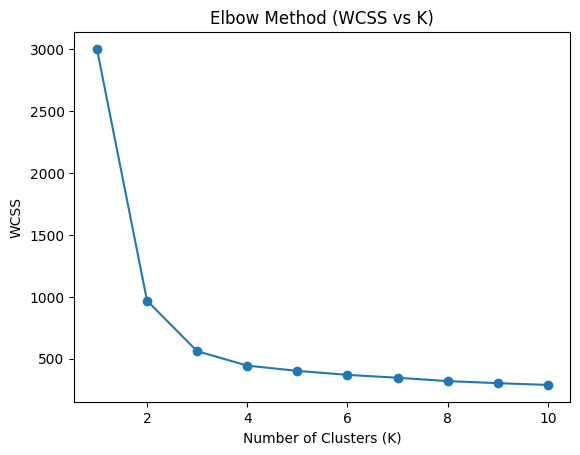

In [ ]:
# Import KMeans and matplotlib
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Compute WCSS for K = 1 to 10
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot the Elbow Curve
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')

# Labels and title
plt.title('Elbow Method (WCSS vs K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

# Show plot
plt.show()

**Optimal K Selection (Markdown)**


---


The elbow method helps identify the optimal number of clusters by observing where the rate of decrease in WCSS slows down significantly.

1) Initially, WCSS decreases sharply as K increases, since more clusters reduce within-cluster variance.
2) After a certain point, the improvement becomes marginal — this point is called the “elbow.”


---


**How to choose K:**

1) Identify the value of K where the curve transitions from steep decline to a more gradual slope.
2) This indicates that adding more clusters does not provide substantial improvement.


---


**Example Interpretation (adjust based on your plot):**

If the elbow appears at K = 3, it suggests that 3 clusters capture the underlying structure effectively without overfitting.


---


**Conclusion:**

Select the K at the elbow point as the optimal number of clusters.
This balances model simplicity and cluster quality.

# Task 3 - K-Means Clustering

In [ ]:
# Choose optimal K (replace with your elbow result, e.g., K=3 or K=4)
optimal_k = 3

# Fit K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add cluster labels to original dataframe
df['cluster'] = clusters

# View sample data with clusters
print(df.head())

#--------------------------------------------------
# Cluster Centroids (Readable Format)
#--------------------------------------------------
print('\n')
print('\n')

# Get centroids (in scaled space)
centroids_scaled = kmeans.cluster_centers_

# Convert centroids back to original scale for interpretation
centroids_original = scaler.inverse_transform(centroids_scaled)

# Create DataFrame for readability
centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1])

print("Cluster Centroids (Original Scale):\n")
print(centroids_df)

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  




Cluster Centroids (Original Scale):

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_sin

**Cluster Interpretation (Markdown)**

(Adjust descriptions based on your centroid values — example below assumes K=3)


---


**Cluster 0: High-Value Loyal Customers**


*   High annual_spend
*   Frequent visits_per_month
*   Low days_since_last_visit
*   Large basket_size


**Interpretation:**

These are premium customers who purchase frequently and spend more per visit.
Business Action: Focus on retention strategies, loyalty programs, and personalized offers.


---


**Cluster 1: Low-Engagement Customers**

*  Low annual_spend
*  Low visits_per_month
*  Small basket_size
*  High days_since_last_visit

**Interpretation:**

These customers are disengaged or at risk of churn.
Business Action: Target with re-engagement campaigns, discounts, or reminders.


---


**Cluster 2: Moderate / Occasional Shoppers**

*  Moderate spend and visits
*  Moderate basket size
*  Moderate recency


**Interpretation:**

Customers with average engagement and spending behavior.
Business Action: Upsell and cross-sell to move them into high-value segment.


---


**Summary**
1) K-Means applied with optimal K
2) Customers segmented into distinct behavioral groups
3) Centroids provide clear, actionable business insights

# Task 4 - Dimensionality Reduction with PCA

In [ ]:
#---------------------------------------------------
# Dimensionality Reduction with PCA
#---------------------------------------------------

# Import PCA
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(df_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# Display first few rows
print(pca_df.head())

print("\n")
#-----------------------------------------------------
#  Explained Variance Ratio
#-----------------------------------------------------

# Print explained variance ratio
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)


#-----------------------------------------------------
#  Feature Loadings (Components)
#-----------------------------------------------------

# Create DataFrame for loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df_scaled.columns,
    index=['PC1', 'PC2']
)

print("PCA Loadings:\n")
print(loadings)

        PC1       PC2
0 -0.333082  0.109379
1 -2.255362  0.048458
2 -0.092905 -0.679257
3 -2.017598 -0.308845
4 -2.917762  0.529368


Explained Variance Ratio:
[0.83560354 0.05568764]
PCA Loadings:

          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


**Interpretation of Principal Components (Markdown)**


---


**Explained Variance Insight**
1) PC1 explains ~83.56% of the total variance → dominant component
2) PC2 explains ~5.57% → secondary, but still useful for additional behavioral separation

This indicates that most customer variation is driven by a single underlying dimension.


---


**PC1: Overall Customer Value & Activity Intensity**

Key loadings (all relatively strong and similar magnitude):

* Positive: annual_spend, basket_size, num_categories_purchased, age, days_since_last_visit

* Negative: visits_per_month

Interpretation:

PC1 represents a composite measure of customer value and purchasing behavior, but with an interesting trade-off:

* Higher spend, larger baskets, and more categories purchased → higher PC1
* Lower visit frequency → also contributes to higher PC1

Business Meaning:

This dimension separates:
* High-value, less frequent bulk buyers (high PC1)
vs
Frequent, lower-spend shoppers (low PC1)

PC1 essentially captures a “value vs frequency” behavioral axis.


---



**PC2: Recency (Customer Freshness)**

Dominant loading:

* days_since_last_visit = 0.91 (very strong)

Other features have minimal influence.

Interpretation:
PC2 is clearly a recency-driven component:

* High PC2 → customers who haven’t visited recently (inactive)
* Low PC2 → recently active customers

Business Meaning:

This dimension separates:
* Active customers (recent visits)
vs
Dormant / at-risk customers

PC2 captures customer engagement freshness independently of value.


---


**Final Conclusion (Markdown)**

* PC1 (83.6%): Represents customer value and purchasing behavior, with a trade-off between frequency and basket size/spend.
* PC2 (5.6%): Represents recency, clearly identifying active vs inactive customers.

**Business Insight:**

* Customer segmentation is primarily driven by value patterns (PC1)
* Recency (PC2) adds an important second layer for identifying churn risk

**Practical Use:**

Use PC1 + PC2 together to segment customers into:
* High-value but infrequent buyers
* Frequent low-value shoppers
* Active vs dormant customers

# Task 5 - Cluster Visualisation

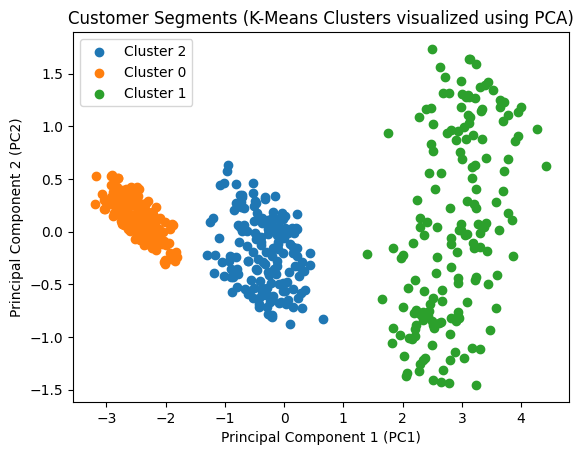

In [ ]:
# Add cluster labels to PCA dataframe
pca_df['cluster'] = df['cluster']

# Create scatter plot
plt.figure()

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

# Labels and title
plt.title('Customer Segments (K-Means Clusters visualized using PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

# Legend
plt.legend()

# Show plot
plt.show()

**Interpretation (Markdown)**

* Each point represents a customer projected into 2D space using PCA.
* Clusters are color-coded to show how K-Means has grouped similar customers.

**What to observe:**

* Clear separation along PC1 indicates strong segmentation based on customer value and behavior.
* Vertical spread (PC2) reflects differences in recency (customer activity).
* Overlapping clusters may indicate similar behavioral patterns between segments.